In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import cv2

import duckietown_code_utils as dcu

%matplotlib inline
%pylab inline

DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
fn = '/code/braitenberg/assets/samples/duckie-images/image2.png'
image1 = dcu.rgb_from_jpg_fn(fn)

In [4]:
image1.shape

(480, 640, 3)

In [5]:
image1.dtype

dtype('uint8')

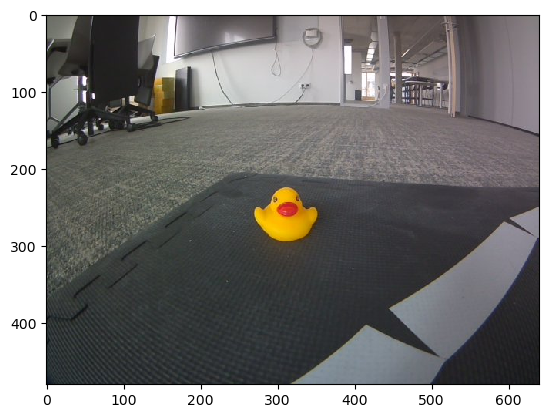

In [6]:
plt.imshow(image1);

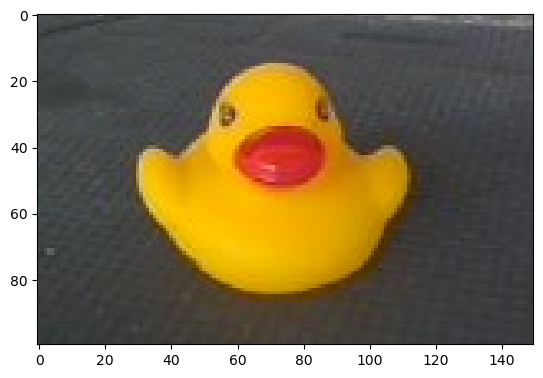

In [7]:
image1_cropped = image1[210:310, 240:390, :]
plt.imshow(image1_cropped);

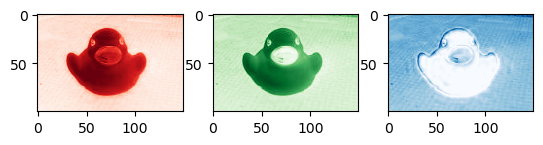

In [8]:
# Break out each color channel
R = image1_cropped[:,:,0]
G = image1_cropped[:,:,1]
B = image1_cropped[:,:,2]

# Visualize with color mappings
f, axarr = plt.subplots(1, 3)
axarr[0].imshow(R, cmap="Reds")
axarr[1].imshow(G, cmap="Greens")
axarr[2].imshow(B, cmap="Blues")
plt.show()

(100, 150)

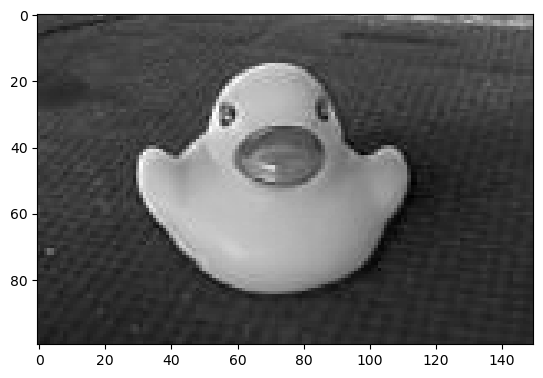

In [10]:
grayscale = np.mean(image1_cropped, axis=2)
plt.imshow(grayscale, cmap='gray');
grayscale.shape

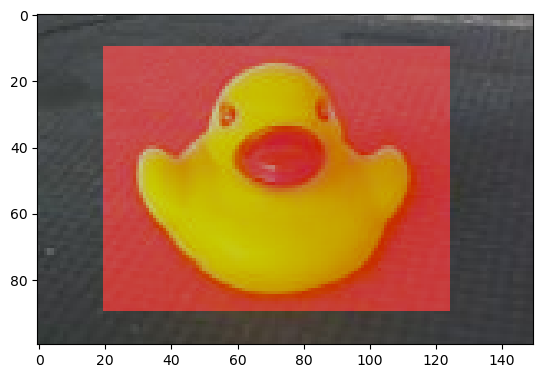

In [11]:
# DRaw a rectangle around the duckie 
image1_copy = image1_cropped.copy()

image1_copy[10:90, 20:125, 0] = 200

plt.imshow(image1_copy);

here open the terminal , go to the terminal and type the following commands 
to open the hsv editor
select the best upper and lower hsv values  and replace them to create the best mask.

$ dts code build
$ dts

to extract the HSV

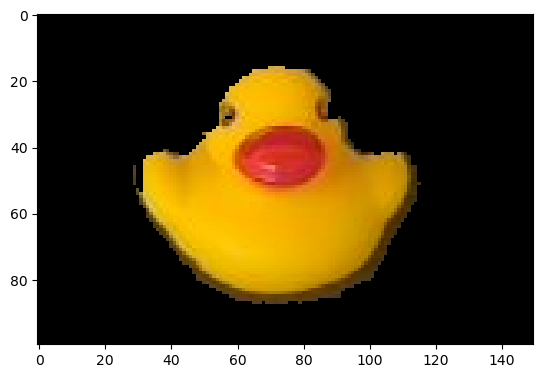

In [29]:
# Change from RGV values to HSV values
hsv = cv2.cvtColor(image1_cropped, cv2.COLOR_RGB2HSV)

# upper and lower HSV values for the image
lower_hsv = np.array([0, 141, 0])
upper_hsv = np.array([179, 255, 255])

# Returns a matrix of 0 or 1 that satisfy the constraint (pixels within our defined bounds)
mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

# Get a "masked image"
masked = cv2.bitwise_and(image1_cropped, image1_cropped, mask=mask)
plt.imshow(masked);

